In [1]:
# Cell 1: Imports and style configuration

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for publication-quality figures
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

print("✓ Imports loaded successfully")

✓ Imports loaded successfully


In [2]:
# Cell 2: CONFIG — PASTE PATHS HERE

# ============================================================
# REQUIRED INPUT FILES (all 3 databases):
# - write_metrics_Supabase.csv
# - write_metrics_MongoDB.csv
# - write_metrics_AstraDB.csv
# ============================================================

# ============================================================
# EDIT THESE FOUR LINES
# ============================================================

# Full path to Supabase write_metrics.csv
supa_csv = r"C:\Users\avyaa\Desktop\Research Stuff\Results\Supa_results\Write\Data\write_metrics_Supabase.csv"

# Full path to MongoDB write_metrics.csv
mongo_csv = r"C:\Users\avyaa\Desktop\Research Stuff\Results\Mongo_results\Write\Data\write_metrics_MongoDB.csv"

# Full path to AstraDB write_metrics.csv
astra_csv = r"C:\Users\avyaa\Desktop\Research Stuff\Results\Astra_results\Write\Data\write_metrics_AstraDB.csv"

# Full path to OUTPUT FOLDER (where figures will be saved)
output_dir = r"C:\Users\avyaa\Desktop\Research Stuff\Results\Figures\Write"

# ============================================================
# DO NOT EDIT BELOW
# ============================================================

# Create output directory if it doesn't exist
os.makedirs(output_dir, exist_ok=True)

# Output filenames
fig3_filename = os.path.join(output_dir, "fig3_write_performance_dual_panel.png")
fig3_outlier_filename = os.path.join(output_dir, "fig3_outliers_write_latency.png")

print("Input files:")
print("  Supabase:", supa_csv)
print("  MongoDB:", mongo_csv)
print("  AstraDB:", astra_csv)
print("\nOutput folder:", output_dir)
print("\nFigures will be saved as:")
print("  Figure 3 (Dual Panel):", fig3_filename)
print("  Figure 3 Outliers (if needed):", fig3_outlier_filename)

# Verify all inputs exist
missing = []
if not os.path.exists(supa_csv):
    missing.append("Supabase")
if not os.path.exists(mongo_csv):
    missing.append("MongoDB")
if not os.path.exists(astra_csv):
    missing.append("AstraDB")

if missing:
    print(f"\n⚠️ MISSING FILES for: {', '.join(missing)}")
    print("Please check your paths!")
else:
    print("\n✓ All input files found!")

Input files:
  Supabase: C:\Users\avyaa\Desktop\Research Stuff\Results\Supa_results\Write\Data\write_metrics_Supabase.csv
  MongoDB: C:\Users\avyaa\Desktop\Research Stuff\Results\Mongo_results\Write\Data\write_metrics_MongoDB.csv
  AstraDB: C:\Users\avyaa\Desktop\Research Stuff\Results\Astra_results\Write\Data\write_metrics_AstraDB.csv

Output folder: C:\Users\avyaa\Desktop\Research Stuff\Results\Figures\Write

Figures will be saved as:
  Figure 3 (Dual Panel): C:\Users\avyaa\Desktop\Research Stuff\Results\Figures\Write\fig3_write_performance_dual_panel.png
  Figure 3 Outliers (if needed): C:\Users\avyaa\Desktop\Research Stuff\Results\Figures\Write\fig3_outliers_write_latency.png

✓ All input files found!


In [3]:
# Cell 3: Load all three databases' metrics and validate

# Load CSVs
df_supa = pd.read_csv(supa_csv)
df_mongo = pd.read_csv(mongo_csv)
df_astra = pd.read_csv(astra_csv)

# Required columns
required = ["query_id", "write_p50_ms", "write_p99_ms", "success_rate_pct"]

# Validate columns
for name, df in [("Supabase", df_supa), ("MongoDB", df_mongo), ("AstraDB", df_astra)]:
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"{name} missing columns: {missing}")

# Sort all by query_id for consistent ordering
df_supa = df_supa.sort_values("query_id").reset_index(drop=True)
df_mongo = df_mongo.sort_values("query_id").reset_index(drop=True)
df_astra = df_astra.sort_values("query_id").reset_index(drop=True)

# Verify all have same write types
write_types = df_supa["query_id"].values
if not (np.array_equal(write_types, df_mongo["query_id"].values) and 
        np.array_equal(write_types, df_astra["query_id"].values)):
    print("⚠️ WARNING: Databases have different write type sets!")
    print("Using intersection of write types...")
    # Get common write types
    common = set(df_supa["query_id"]) & set(df_mongo["query_id"]) & set(df_astra["query_id"])
    write_types = sorted(common)
    df_supa = df_supa[df_supa["query_id"].isin(write_types)].sort_values("query_id").reset_index(drop=True)
    df_mongo = df_mongo[df_mongo["query_id"].isin(write_types)].sort_values("query_id").reset_index(drop=True)
    df_astra = df_astra[df_astra["query_id"].isin(write_types)].sort_values("query_id").reset_index(drop=True)

print("✓ Data loaded and validated")
print(f"  Write types: {len(write_types)} ({list(write_types)})")
print(f"  Supabase rows: {len(df_supa)}")
print(f"  MongoDB rows: {len(df_mongo)}")
print(f"  AstraDB rows: {len(df_astra)}")

⚠️ WARNING: Databases have different write type sets!
Using intersection of write types...
✓ Data loaded and validated
  Write types: 9 (['W1A', 'W1B', 'W1C', 'W2', 'W3B', 'W4', 'W5', 'W7A', 'W7B'])
  Supabase rows: 9
  MongoDB rows: 9
  AstraDB rows: 9


In [4]:
# Cell 4: Outlier Detection (Write Type Level - p99 based)

print("\n" + "=" * 60)
print("OUTLIER DETECTION (Latency)")
print("=" * 60)

# Combine all p99 values to compute overall statistics
all_p99 = np.concatenate([
    df_supa["write_p99_ms"].values,
    df_mongo["write_p99_ms"].values,
    df_astra["write_p99_ms"].values
])
all_p50 = np.concatenate([
    df_supa["write_p50_ms"].values,
    df_mongo["write_p50_ms"].values,
    df_astra["write_p50_ms"].values
])

# Overall statistics
overall_median_p50 = np.nanmedian(all_p50)
overall_median_p99 = np.nanmedian(all_p99)
overall_max_p99 = np.nanmax(all_p99)

print(f"Overall median p50: {overall_median_p50:.2f} ms")
print(f"Overall median p99: {overall_median_p99:.2f} ms")
print(f"Overall max p99: {overall_max_p99:.2f} ms")

# Detect outlier write types (any database with p99 > thresholds)
outlier_writes = []
normal_writes = []

for i, w in enumerate(write_types):
    # Get p99 values for this write type across all databases
    w_p99_vals = [
        df_supa.iloc[i]["write_p99_ms"],
        df_mongo.iloc[i]["write_p99_ms"],
        df_astra.iloc[i]["write_p99_ms"]
    ]
    max_w_p99 = np.nanmax(w_p99_vals)
    
    # Flag if ANY database shows extreme p99 for this write type
    if max_w_p99 > 10 * overall_median_p50 or max_w_p99 > 5 * overall_median_p99:
        outlier_writes.append(w)
        print(f"\n🚨 OUTLIER WRITE TYPE: {w}")
        print(f"   Max p99 across DBs: {max_w_p99:.2f} ms ({max_w_p99/overall_median_p50:.1f}× median p50)")
    else:
        normal_writes.append(w)

if len(outlier_writes) > 0:
    print(f"\n✓ Detected {len(outlier_writes)} outlier write type(s): {outlier_writes}")
    print(f"✓ Main figure will show {len(normal_writes)} normal write types")
    print(f"✓ Outlier figure will be generated separately")
else:
    print(f"\n✓ No extreme outliers detected")
    print(f"✓ All {len(write_types)} write types in main figure")
    normal_writes = list(write_types)

# Filter masks
mask_normal = [w in normal_writes for w in write_types]
mask_outlier = [w in outlier_writes for w in write_types]


OUTLIER DETECTION (Latency)
Overall median p50: 197.61 ms
Overall median p99: 261.78 ms
Overall max p99: 1979.70 ms

🚨 OUTLIER WRITE TYPE: W3B
   Max p99 across DBs: 1979.70 ms (10.0× median p50)

✓ Detected 1 outlier write type(s): ['W3B']
✓ Main figure will show 8 normal write types
✓ Outlier figure will be generated separately



MAIN DUAL-PANEL FIGURE GENERATION
✓ Figure 3 (Dual Panel) saved: C:\Users\avyaa\Desktop\Research Stuff\Results\Figures\Write\fig3_write_performance_dual_panel.png


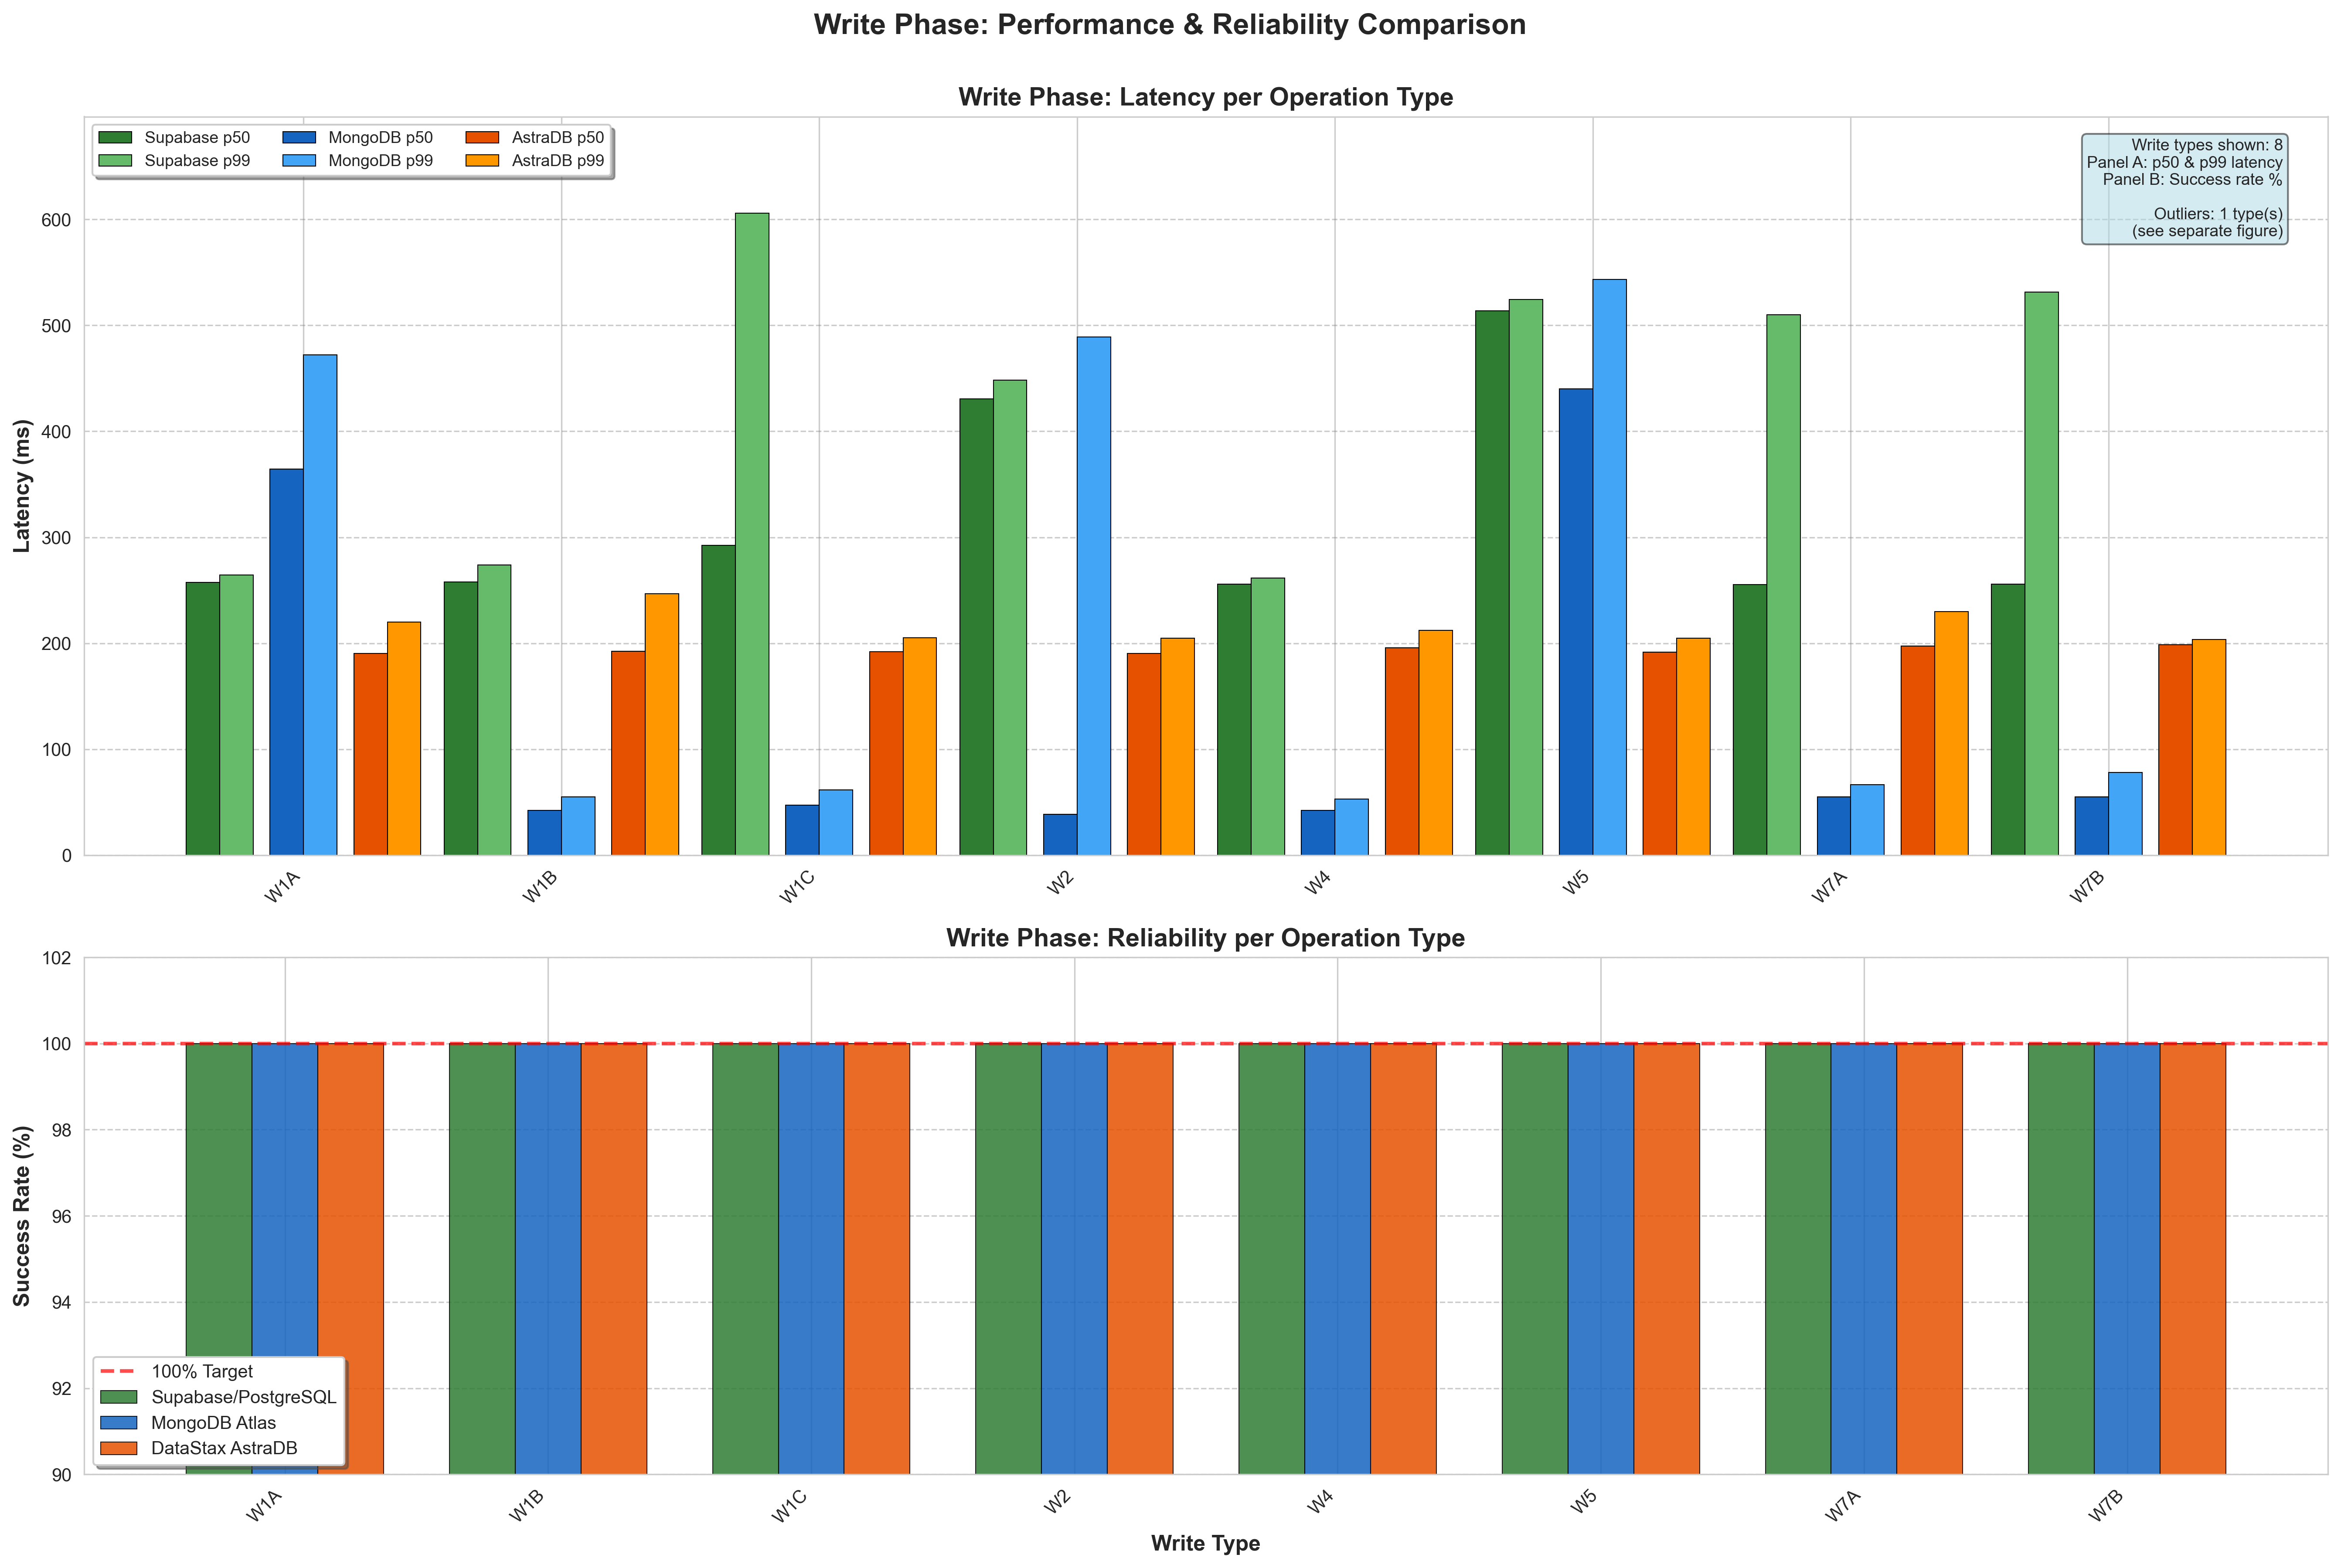

In [5]:
# Cell 5: Figure 3 - Write Performance Dual Panel (Normal Write Types)

print("\n" + "=" * 60)
print("MAIN DUAL-PANEL FIGURE GENERATION")
print("=" * 60)

# Filter to normal write types
writes_normal = [w for w in write_types if w in normal_writes]
n_writes_normal = len(writes_normal)

# Extract data for normal write types
supa_p50_normal = df_supa[mask_normal]["write_p50_ms"].values
supa_p99_normal = df_supa[mask_normal]["write_p99_ms"].values
supa_success_normal = df_supa[mask_normal]["success_rate_pct"].values

mongo_p50_normal = df_mongo[mask_normal]["write_p50_ms"].values
mongo_p99_normal = df_mongo[mask_normal]["write_p99_ms"].values
mongo_success_normal = df_mongo[mask_normal]["success_rate_pct"].values

astra_p50_normal = df_astra[mask_normal]["write_p50_ms"].values
astra_p99_normal = df_astra[mask_normal]["write_p99_ms"].values
astra_success_normal = df_astra[mask_normal]["success_rate_pct"].values

# Create figure with 2 subplots stacked vertically
fig, (ax_lat, ax_success) = plt.subplots(2, 1, figsize=(18, 12), 
                                          gridspec_kw={'height_ratios': [1, 0.7]})

# ============================================================
# PANEL A (TOP): Latency Bars (p50 & p99)
# ============================================================

x = np.arange(n_writes_normal)
width = 0.13
offset = width * 0.5

# Positions for each bar
pos_supa_p50 = x - 2.5*width - offset
pos_supa_p99 = x - 1.5*width - offset
pos_mongo_p50 = x - 0.5*width
pos_mongo_p99 = x + 0.5*width
pos_astra_p50 = x + 1.5*width + offset
pos_astra_p99 = x + 2.5*width + offset

# Create latency bars
ax_lat.bar(pos_supa_p50, supa_p50_normal, width, 
           label='Supabase p50', color='#2E7D32', edgecolor='black', linewidth=0.5)
ax_lat.bar(pos_supa_p99, supa_p99_normal, width, 
           label='Supabase p99', color='#66BB6A', edgecolor='black', linewidth=0.5)
ax_lat.bar(pos_mongo_p50, mongo_p50_normal, width, 
           label='MongoDB p50', color='#1565C0', edgecolor='black', linewidth=0.5)
ax_lat.bar(pos_mongo_p99, mongo_p99_normal, width, 
           label='MongoDB p99', color='#42A5F5', edgecolor='black', linewidth=0.5)
ax_lat.bar(pos_astra_p50, astra_p50_normal, width, 
           label='AstraDB p50', color='#E65100', edgecolor='black', linewidth=0.5)
ax_lat.bar(pos_astra_p99, astra_p99_normal, width, 
           label='AstraDB p99', color='#FF9800', edgecolor='black', linewidth=0.5)

# Adaptive Y-axis for latency panel
all_lat_normal = np.concatenate([supa_p50_normal, supa_p99_normal, mongo_p50_normal,
                                 mongo_p99_normal, astra_p50_normal, astra_p99_normal])
max_lat = np.nanmax(all_lat_normal)
y_range_lat = max_lat

if y_range_lat < 20:
    padding_lat = 10
elif y_range_lat < 100:
    padding_lat = 20
else:
    padding_lat = max_lat * 0.15

y_limit_lat = max_lat + padding_lat

# Panel A properties
ax_lat.set_ylabel('Latency (ms)', fontweight='bold', fontsize=12)
ax_lat.set_title('Write Phase: Latency per Operation Type', fontweight='bold', fontsize=14)
ax_lat.set_xticks(x)
ax_lat.set_xticklabels(writes_normal, fontsize=10, rotation=45, ha='right')
ax_lat.set_ylim(0, y_limit_lat)
ax_lat.yaxis.grid(True, linestyle='--', alpha=0.4, linewidth=0.8, color='gray')
ax_lat.set_axisbelow(True)
ax_lat.legend(loc='upper left', ncol=3, frameon=True, shadow=True, fontsize=9)

# ============================================================
# PANEL B (BOTTOM): Success Rate Bars
# ============================================================

width_success = 0.25

pos_supa_success = x - width_success
pos_mongo_success = x
pos_astra_success = x + width_success

# Create success rate bars
ax_success.bar(pos_supa_success, supa_success_normal, width_success,
               label='Supabase/PostgreSQL', color='#2E7D32', 
               edgecolor='black', linewidth=0.5, alpha=0.85)
ax_success.bar(pos_mongo_success, mongo_success_normal, width_success,
               label='MongoDB Atlas', color='#1565C0', 
               edgecolor='black', linewidth=0.5, alpha=0.85)
ax_success.bar(pos_astra_success, astra_success_normal, width_success,
               label='DataStax AstraDB', color='#E65100', 
               edgecolor='black', linewidth=0.5, alpha=0.85)

# Baseline at 100%
ax_success.axhline(y=100, color='red', linestyle='--', linewidth=2, 
                   alpha=0.7, label='100% Target')

# Panel B properties
ax_success.set_xlabel('Write Type', fontweight='bold', fontsize=12)
ax_success.set_ylabel('Success Rate (%)', fontweight='bold', fontsize=12)
ax_success.set_title('Write Phase: Reliability per Operation Type', fontweight='bold', fontsize=14)
ax_success.set_xticks(x)
ax_success.set_xticklabels(writes_normal, fontsize=10, rotation=45, ha='right')
ax_success.set_ylim(90, 102)  # Focus on 90-102% range for visibility
ax_success.yaxis.grid(True, linestyle='--', alpha=0.4, linewidth=0.8, color='gray')
ax_success.set_axisbelow(True)
ax_success.legend(loc='lower left', frameon=True, shadow=True, fontsize=10)

# Overall figure title
fig.suptitle('Write Phase: Performance & Reliability Comparison', 
             fontweight='bold', fontsize=16, y=0.995)

# Stats box on latency panel
stats_text = (
    f"Write types shown: {n_writes_normal}\n"
    f"Panel A: p50 & p99 latency\n"
    f"Panel B: Success rate %"
)
if len(outlier_writes) > 0:
    stats_text += f"\n\nOutliers: {len(outlier_writes)} type(s)\n(see separate figure)"

ax_lat.text(0.98, 0.97, stats_text, transform=ax_lat.transAxes,
            fontsize=9, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5, edgecolor='black'))

plt.tight_layout(rect=[0, 0, 1, 0.99])
plt.savefig(fig3_filename, dpi=300, bbox_inches='tight')
print(f"✓ Figure 3 (Dual Panel) saved: {fig3_filename}")
plt.show()


OUTLIER FIGURE GENERATION
✓ Outlier figure saved: C:\Users\avyaa\Desktop\Research Stuff\Results\Figures\Write\fig3_outliers_write_latency.png


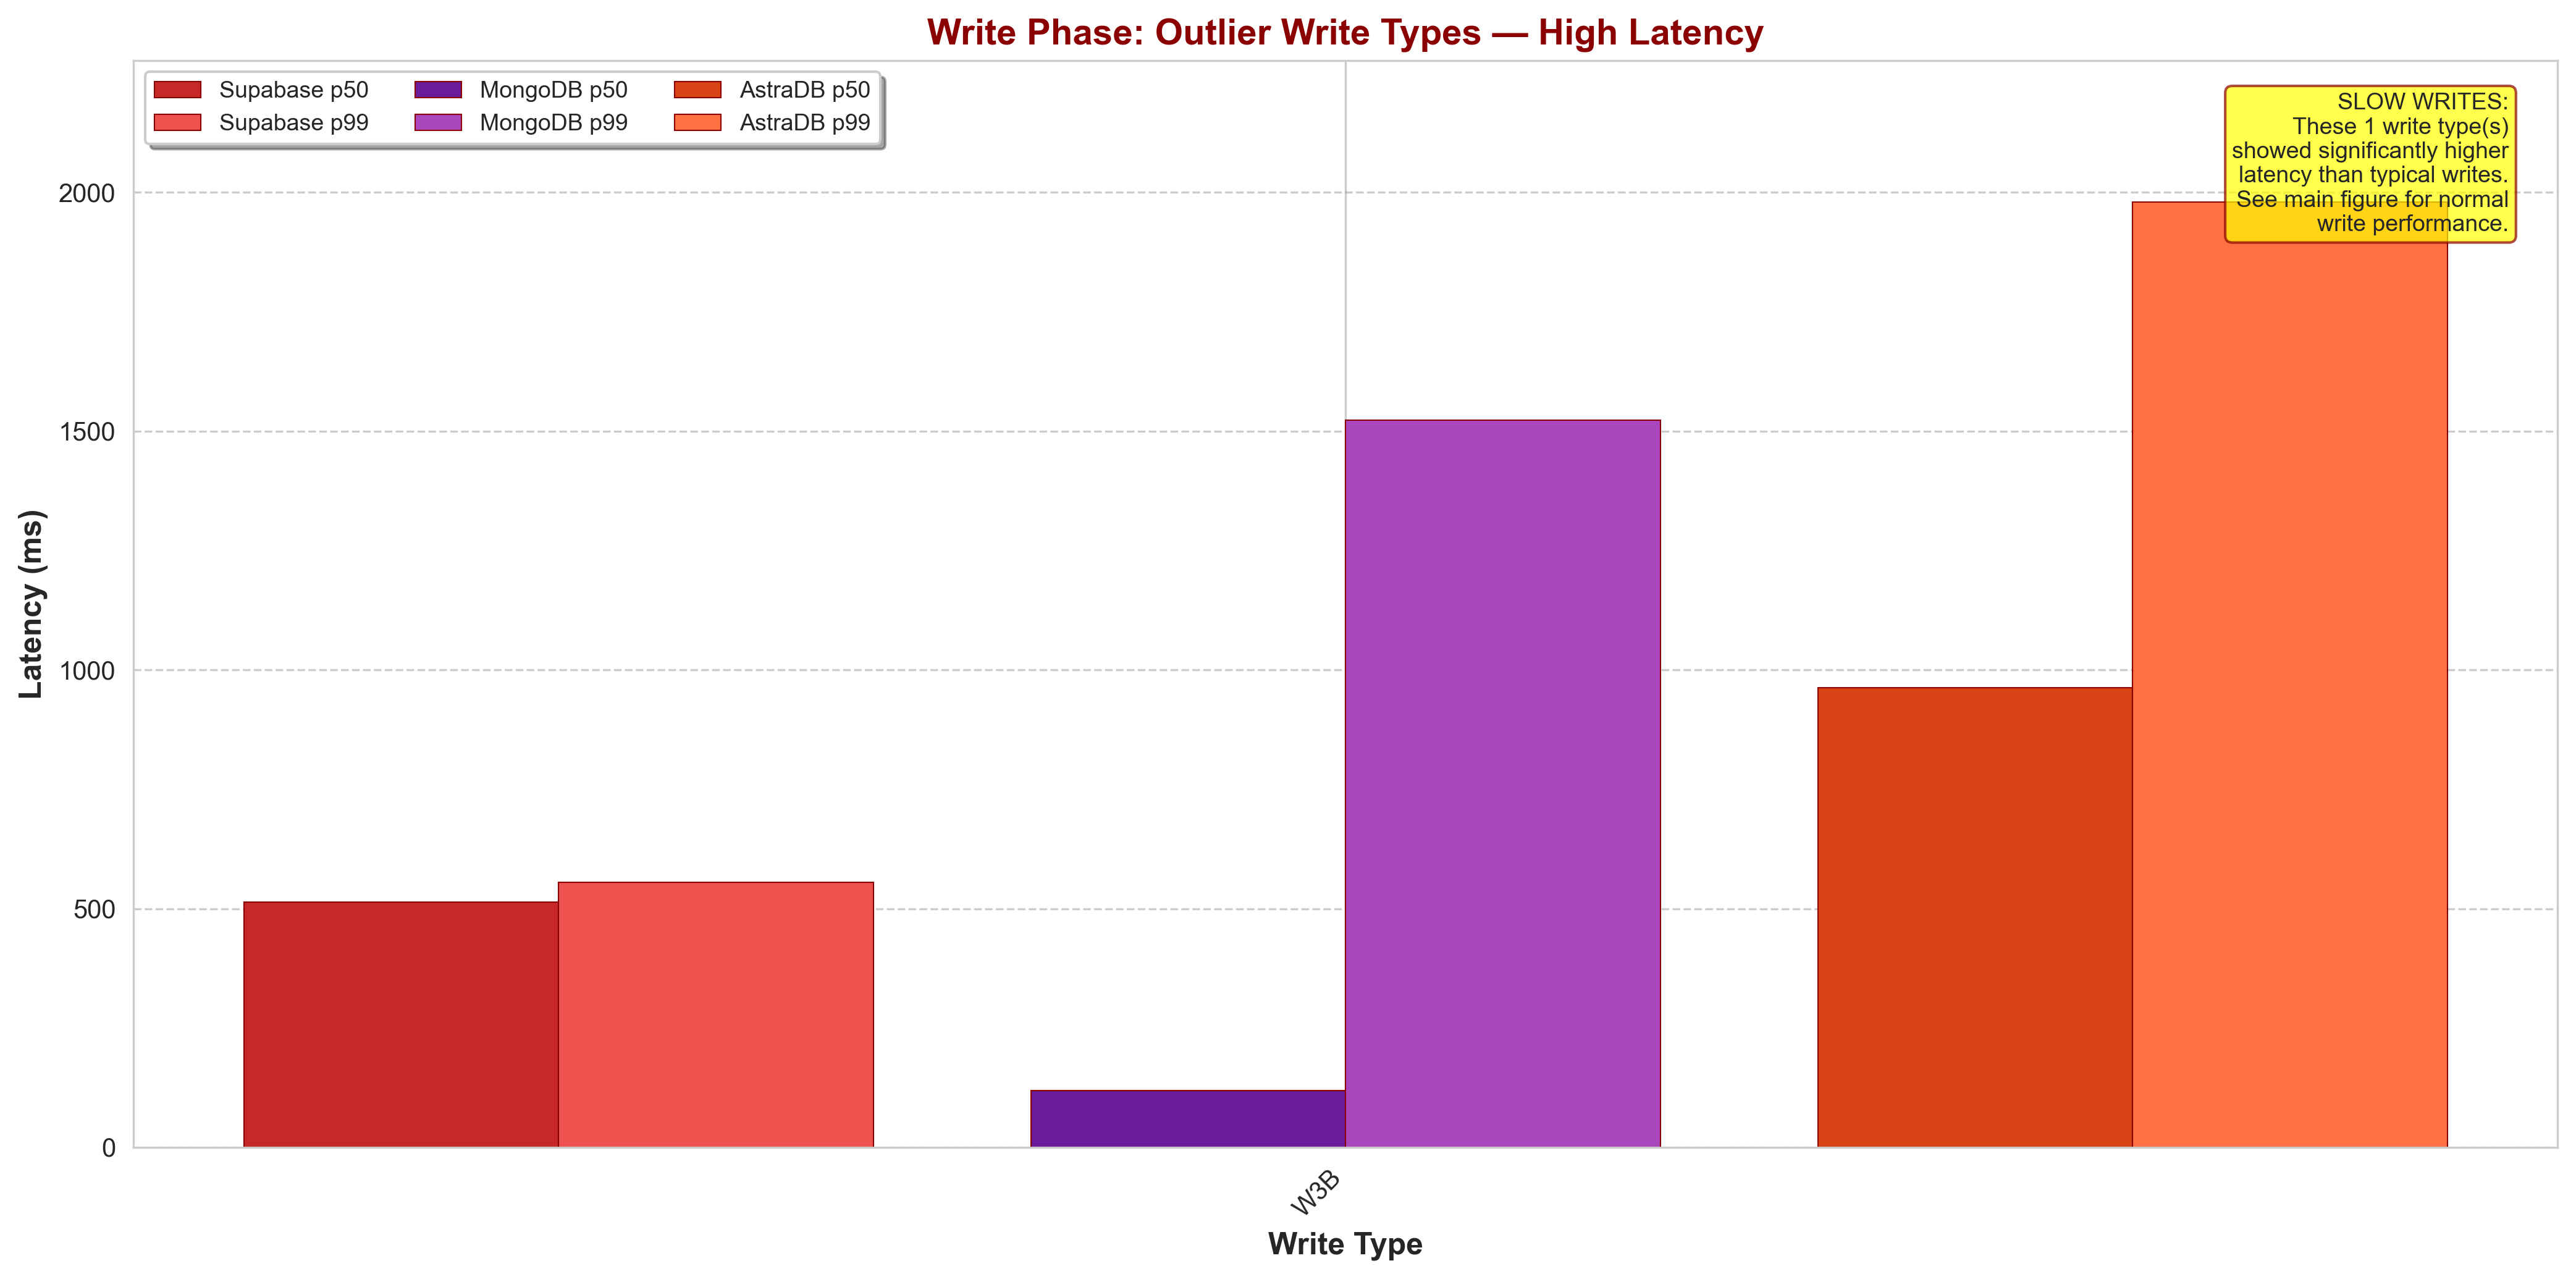

In [6]:
# Cell 6: Figure 3 Outliers - Latency panel for outlier write types

if len(outlier_writes) > 0:
    print("\n" + "=" * 60)
    print("OUTLIER FIGURE GENERATION")
    print("=" * 60)
    
    # Filter to outlier write types
    writes_outlier = [w for w in write_types if w in outlier_writes]
    n_writes_outlier = len(writes_outlier)
    
    supa_p50_outlier = df_supa[mask_outlier]["write_p50_ms"].values
    supa_p99_outlier = df_supa[mask_outlier]["write_p99_ms"].values
    mongo_p50_outlier = df_mongo[mask_outlier]["write_p50_ms"].values
    mongo_p99_outlier = df_mongo[mask_outlier]["write_p99_ms"].values
    astra_p50_outlier = df_astra[mask_outlier]["write_p50_ms"].values
    astra_p99_outlier = df_astra[mask_outlier]["write_p99_ms"].values
    
    fig_out, ax_out = plt.subplots(figsize=(14, 7))
    
    # Bar positioning
    x_out = np.arange(n_writes_outlier)
    width = 0.13
    offset = width * 0.5
    
    # Positions
    pos_supa_p50 = x_out - 2.5*width - offset
    pos_supa_p99 = x_out - 1.5*width - offset
    pos_mongo_p50 = x_out - 0.5*width
    pos_mongo_p99 = x_out + 0.5*width
    pos_astra_p50 = x_out + 1.5*width + offset
    pos_astra_p99 = x_out + 2.5*width + offset
    
    # Create bars (RED color scheme)
    ax_out.bar(pos_supa_p50, supa_p50_outlier, width, 
               label='Supabase p50', color='#C62828', edgecolor='darkred', linewidth=0.5)
    ax_out.bar(pos_supa_p99, supa_p99_outlier, width, 
               label='Supabase p99', color='#EF5350', edgecolor='darkred', linewidth=0.5)
    ax_out.bar(pos_mongo_p50, mongo_p50_outlier, width, 
               label='MongoDB p50', color='#6A1B9A', edgecolor='darkred', linewidth=0.5)
    ax_out.bar(pos_mongo_p99, mongo_p99_outlier, width, 
               label='MongoDB p99', color='#AB47BC', edgecolor='darkred', linewidth=0.5)
    ax_out.bar(pos_astra_p50, astra_p50_outlier, width, 
               label='AstraDB p50', color='#D84315', edgecolor='darkred', linewidth=0.5)
    ax_out.bar(pos_astra_p99, astra_p99_outlier, width, 
               label='AstraDB p99', color='#FF7043', edgecolor='darkred', linewidth=0.5)
    
    # Y-axis limits
    all_lat_outlier = np.concatenate([supa_p50_outlier, supa_p99_outlier, mongo_p50_outlier,
                                      mongo_p99_outlier, astra_p50_outlier, astra_p99_outlier])
    out_max = np.nanmax(all_lat_outlier)
    out_min = np.nanmin(all_lat_outlier)
    
    # Use log scale if range is extreme (>100×)
    if out_max / max(out_min, 1) > 100:
        ax_out.set_yscale('log')
        ylabel = 'Latency (ms) — LOG SCALE'
        print(f"  Using log scale (range: {out_min:.2f} to {out_max:.2f} ms)")
    else:
        ylabel = 'Latency (ms)'
        ax_out.set_ylim(0, out_max * 1.15)
    
    # Axis properties
    ax_out.set_xlabel('Write Type', fontweight='bold', fontsize=12)
    ax_out.set_ylabel(ylabel, fontweight='bold', fontsize=12)
    ax_out.set_title('Write Phase: Outlier Write Types — High Latency', 
                     fontweight='bold', fontsize=14, color='darkred')
    ax_out.set_xticks(x_out)
    ax_out.set_xticklabels(writes_outlier, fontsize=10, rotation=45, ha='right')
    ax_out.yaxis.grid(True, linestyle='--', alpha=0.4, linewidth=0.8, color='gray')
    ax_out.set_axisbelow(True)
    ax_out.legend(loc='upper left', ncol=3, frameon=True, shadow=True, fontsize=9)
    
    # Warning box
    warn_text = (
        f"SLOW WRITES:\n"
        f"These {n_writes_outlier} write type(s)\n"
        f"showed significantly higher\n"
        f"latency than typical writes.\n"
        f"See main figure for normal\n"
        f"write performance."
    )
    ax_out.text(0.98, 0.97, warn_text, transform=ax_out.transAxes,
                fontsize=9, verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7, edgecolor='darkred'))
    
    plt.tight_layout()
    plt.savefig(fig3_outlier_filename, dpi=300, bbox_inches='tight')
    print(f"✓ Outlier figure saved: {fig3_outlier_filename}")
    plt.show()
else:
    print("\n✓ No outliers detected — skipping outlier figure")

In [7]:
# Cell 7: Summary

print("\n" + "=" * 60)
print("WRITE FIGURES GENERATION COMPLETE")
print("=" * 60)

print(f"\n📊 Databases processed: Supabase, MongoDB, AstraDB")
print(f"📁 Figures saved to: {output_dir}\n")

if len(outlier_writes) > 0:
    print(f"  Figure 3 (Main Dual Panel): {os.path.basename(fig3_filename)}")
    print(f"    └─ {len(normal_writes)} normal write types")
    print(f"    └─ Panel A: Latency (p50 & p99)")
    print(f"    └─ Panel B: Success rates")
    print(f"  Figure 3 (Outliers): {os.path.basename(fig3_outlier_filename)}")
    print(f"    └─ {len(outlier_writes)} outlier write type(s): {outlier_writes}")
else:
    print(f"  Figure 3 (Dual Panel): {os.path.basename(fig3_filename)}")
    print(f"    └─ All {len(write_types)} write types (no outliers)")
    print(f"    └─ Panel A: Latency (p50 & p99)")
    print(f"    └─ Panel B: Success rates")

print("\n✓ All figures generated successfully!")
print("\n📌 Key insights to look for:")
print("  - Panel A: Which database has lowest write latency?")
print("  - Panel B: Which database has best reliability (closest to 100%)?")
if len(outlier_writes) > 0:
    print("  - Outlier figure: Why these write types so slow?")


WRITE FIGURES GENERATION COMPLETE

📊 Databases processed: Supabase, MongoDB, AstraDB
📁 Figures saved to: C:\Users\avyaa\Desktop\Research Stuff\Results\Figures\Write

  Figure 3 (Main Dual Panel): fig3_write_performance_dual_panel.png
    └─ 8 normal write types
    └─ Panel A: Latency (p50 & p99)
    └─ Panel B: Success rates
  Figure 3 (Outliers): fig3_outliers_write_latency.png
    └─ 1 outlier write type(s): ['W3B']

✓ All figures generated successfully!

📌 Key insights to look for:
  - Panel A: Which database has lowest write latency?
  - Panel B: Which database has best reliability (closest to 100%)?
  - Outlier figure: Why these write types so slow?
